In [416]:
#installing required library 
import pandas as pd 
import numpy as np 


In [417]:
#importing data 
df = pd.read_csv('dataset/spam.csv',encoding = 'latin1' )

In [418]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
3491,ham,I will reach office around &lt;DECIMAL&gt; . ...,NaN,NaN,NaN
509,ham,Your opinion about me? 1. Over 2. Jada 3. Kusr...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
1334,ham,Oh ! A half hour is much longer in Syria than ...,NaN,NaN,NaN
2492,ham,No drama Pls.i have had enough from you and fa...,NaN,NaN,NaN


In [419]:
df.shape

(5572, 5)

# data cleaning 

In [420]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [421]:
#dropping unwanted columns from the data...
df = df.drop(columns=(['Unnamed: 2','Unnamed: 3','Unnamed: 4']))

In [422]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   v1      5572 non-null   object
 1   v2      5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [423]:
df.sample(5)

,v1,v2
5306,ham,Ill be at yours in about 3 mins but look out f...
4032,ham,I am taking you for italian food. How about a ...
840,ham,I luv u soo much u donåÕt understand how speci...
1241,ham,"I want to show you the world, princess :) how ..."
4979,ham,So what u doing today?


In [424]:
df.rename(columns = {'v1':'target', 'v2':'text'}, inplace =True)

In [425]:
df.sample(5)

,target,text
4526,ham,Understand. his loss is my gain :) so do you w...
4246,spam,Text PASS to 69669 to collect your polyphonic ...
5435,ham,I'm wif him now buying tix lar...
672,spam,Get ur 1st RINGTONE FREE NOW! Reply to this ms...
1971,ham,Enjoy ur life. . Good night


In [426]:
from sklearn.preprocessing import LabelEncoder 
encoder = LabelEncoder()

In [427]:
#transforming the data
df['target']=encoder.fit_transform(df['target'])

In [428]:
df.sample(5)

,target,text
1147,0,Ok... Help me ask if she's working tmr a not?
1457,1,CLAIRE here am havin borin time & am now alone...
2129,0,Mine here like all fr china then so noisy.
4522,0,Actually I decided I was too hungry so I haven...
1321,0,"I wake up long ago already... Dunno, what othe..."


In [429]:
#checking for null values...
df.isnull().sum()

target    0
text      0
dtype: int64

In [430]:
#checking for duplicates 
df.duplicated().sum()

403

In [431]:
#removing the duplicates 
df = df.drop_duplicates(keep="first")

In [432]:
#checking after duplicates has been dropped from the data 
df.duplicated().sum()

0

In [433]:
#checking the shapeof the data 
df.shape

(5169, 2)

# EDA

In [434]:
#lets count the value of the data 
df['target'].value_counts()

0    4516
1     653
Name: target, dtype: int64

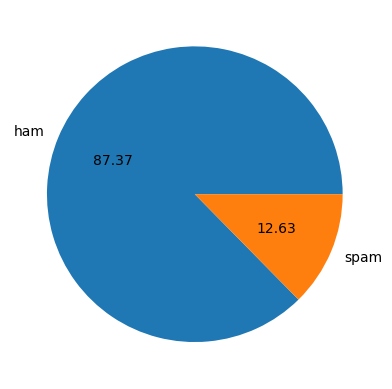

In [435]:
#drawing the pie chart for the dataset 
import matplotlib.pyplot as plt 
plt.pie(df['target'].value_counts(), labels =['ham', 'spam'], autopct= '%0.2f')
plt.show()

<BarContainer object of 2 artists>

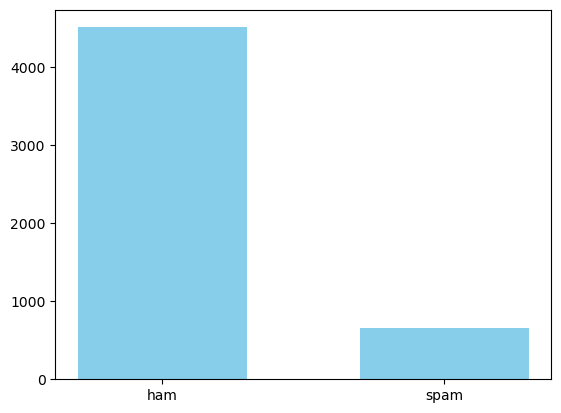

In [436]:
#lets plot the bargrph for the it 
plt.bar(['ham', 'spam'],df['target'].value_counts(), color='skyblue', width =0.6)

In [437]:
#importing nltk 
import nltk

In [438]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/santoshkhatri/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [439]:
#checking the length of the email and adding it to new column 
df['num_character']=df['text'].apply(len)

In [440]:
df.head()

,target,text,num_character
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [441]:
#counting the number of words in the email and storing in the new column 
df['num_words']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [442]:
df.head()

,target,text,num_character,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [443]:
#checking number of sentance used in every email 
df['num_sentance']=df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [444]:
df.head()

,target,text,num_character,num_words,num_sentance
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [445]:
df[['num_character','num_words','num_sentance']].describe()

,num_character,num_words,num_sentance
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.453279,1.947185
std,58.236293,13.324793,1.362406
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,28.000000


In [446]:
#checking for individual ham 
df[df['target']==0][['num_character','num_words','num_sentance']].describe()
    

,num_character,num_words,num_sentance
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.120903,1.799601
std,56.358207,13.493725,1.278465
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,28.000000


In [447]:
#describing data for spam
df[df['target']==1][['num_character','num_words','num_sentance']].describe()

,num_character,num_words,num_sentance
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.967841
std,30.137753,7.008418,1.483201
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,8.000000


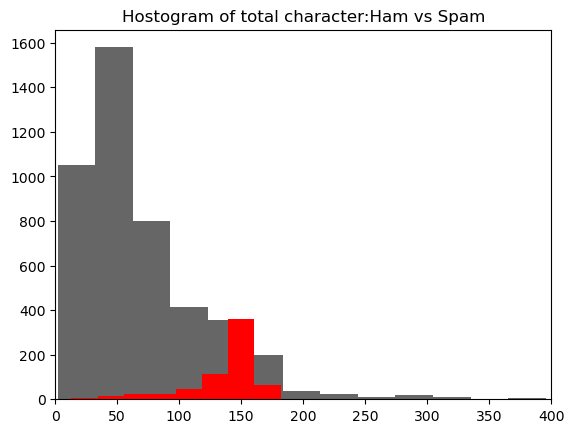

In [448]:
#drawing hiostogram from ham and spam 
plt.hist(df[df['target']==0]['num_character'],bins=30,alpha=0.6,color='black',label ='ham')
plt.hist(df[df['target']==1]['num_character'],color='red')
plt.title('Hostogram of total character:Ham vs Spam')
plt.xlim(0,400)
plt.show()

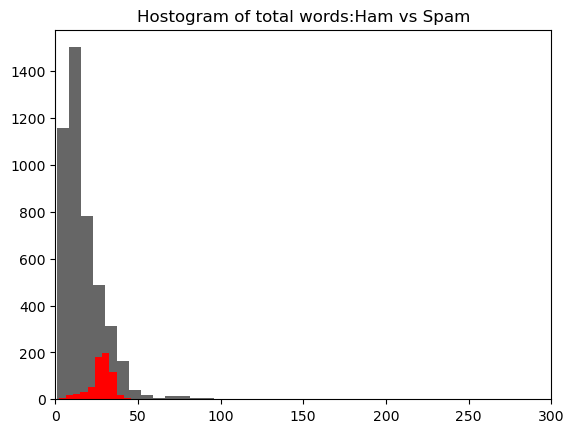

In [449]:
#drawing hiostogram from ham and spam for words 
plt.hist(df[df['target']==0]['num_words'],bins=30,alpha=0.6,color='black',label ='ham')
plt.hist(df[df['target']==1]['num_words'],color='red')
plt.title('Hostogram of total words:Ham vs Spam')
plt.xlim(0,300)
plt.show()

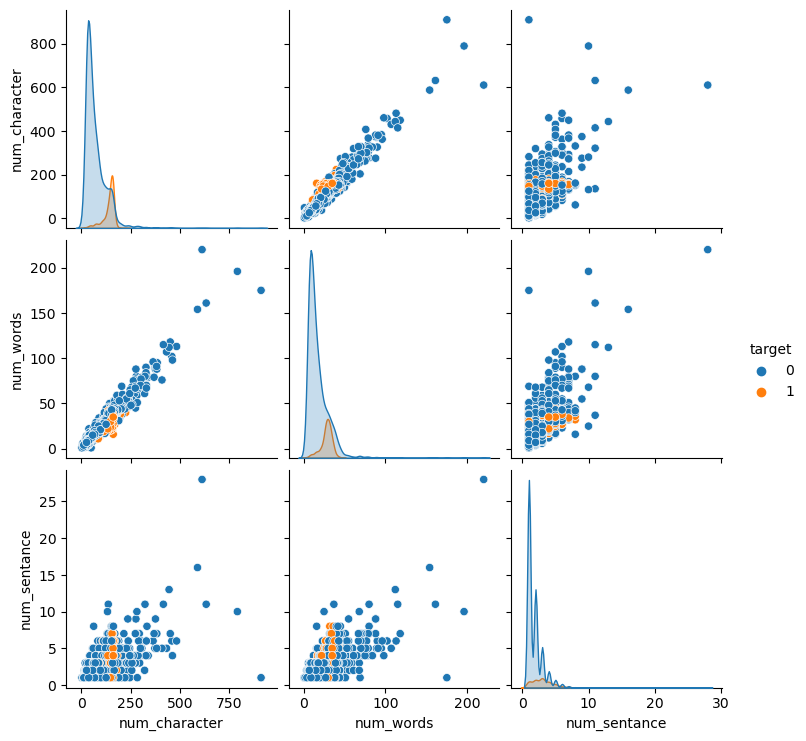

In [450]:
#checking its relation in pairplot 
import seaborn as sns 
sns.pairplot(df,hue="target")
plt.show()

/var/folders/vl/bzb4z1n52mv9g_f37flptljh0000gn/T/ipykernel_88363/1784379384.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(),annot = True)


<Axes: >

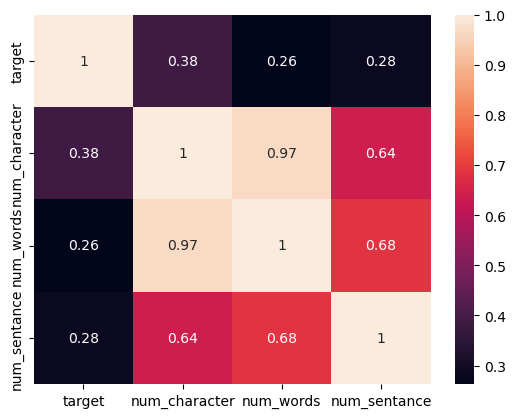

In [451]:
#checking correlation 
sns.heatmap(df.corr(),annot = True)

# data/text prepprocessing 
1.lowercase
2.tokenization
3.removing special character 
4.removing stop words and punctuation 
5.stemming/lemitization


In [452]:
##making function to text preprocessing 
#for checking the stopwords 
from nltk.corpus import stopwords 

import string 
from nltk.stem.porter import PorterStemmer 
ps = PorterStemmer()


def transform_text(text):
    text  = text.lower()  #converting text to lowercase 
    text = nltk.word_tokenize(text)
    
    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)
    
    text = y[:]
    y.clear()
    for i in text:
        if i not in stopwords.words("english") and i not in string.punctuation:
            y.append(i)
    
    text = y[:]
    y.clear()
    
    for i in text:
        y.append(ps.stem(i))
    
    return " ".join(y)

In [453]:
df['transform_text']=df['text'].apply(transform_text)

In [454]:
df.head()

,target,text,num_character,num_words,num_sentance,transform_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [455]:
#making wordcloud 
from wordcloud import WordCloud
wc = WordCloud(width=1500, height =900, min_font_size = 10, background_color = "white")

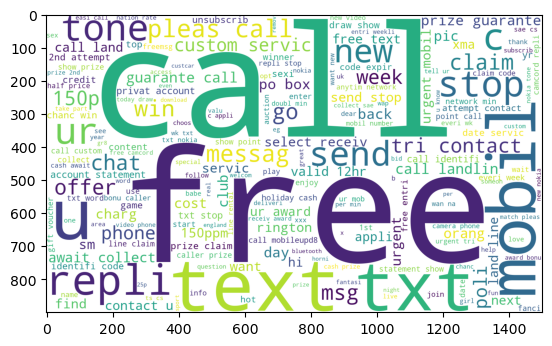

In [456]:
#generating spam wordcloud... 

spam_wc = wc.generate(df[df['target']==1]['transform_text'].str.cat(sep=" "))
plt.imshow(spam_wc)

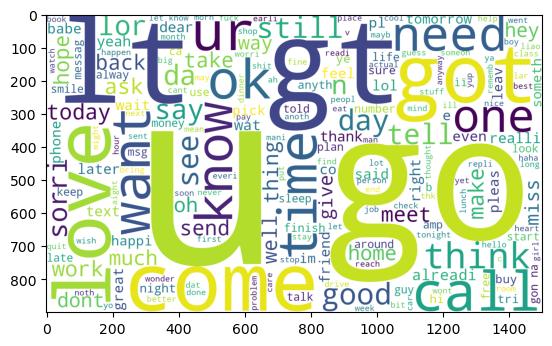

In [457]:
spam_wc = wc.generate(df[df['target']==0]['transform_text'].str.cat(sep=" "))
plt.imshow(spam_wc)

# Model building 


In [503]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer()

In [504]:
X = tfidf.fit_transform(df['transform_text']).toarray()

In [505]:
X.shape

(5169, 6708)

In [506]:
y = df['target'].values

In [507]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [508]:
from sklearn.model_selection import train_test_split 

In [509]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size =0.2,random_state=2)

In [510]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score,classification_report

In [511]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [512]:
#training model 
gnb.fit(X_train,y_train)
y_pred1=gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1,average='macro'))

0.8762088974854932
[[793 103]
 [ 25 113]]
0.7462929004799421


In [513]:
#training another model 
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2,average='macro'))

0.9593810444874274
[[896   0]
 [ 42  96]]
0.9776119402985075


In [514]:
#training another model 
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3,average='macro'))

0.9700193423597679
[[893   3]
 [ 28 110]]
0.9715247950957501


In [515]:
#importing few other model for better learning 
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.ensemble import AdaBoostClassifier 
from sklearn.ensemble import BaggingClassifier 
from sklearn.ensemble import ExtraTreesClassifier 
from sklearn.ensemble import GradientBoostingClassifier 
from xgboost import XGBClassifier 

In [471]:
#making object of all the models accordingly 
lr = LogisticRegression()
svc = SVC(kernel ='sigmoid')
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth =5)
##knc = KNeighborsClassifier()
rfc = RandomForestClassifier(n_estimators = 50, random_state = 2)
abc = AdaBoostClassifier(n_estimators = 50, random_state = 2)
bc = BaggingClassifier(n_estimators = 50, random_state = 2)
etc = ExtraTreesClassifier(n_estimators = 50, random_state = 2)
rbc =GradientBoostingClassifier(n_estimators = 50, random_state = 2)
xbc = XGBClassifier(n_estimators = 50, random_state = 2)

In [472]:
#making dictionary of machine learning algorithm 
clfs = {
    'LR':lr,
    'SVC':svc,
    'MNB':mnb,
    'DTC':dtc,
    ##'KNC':knc,
    'RFC':rfc,
    'ABC':abc,
    'BC':bc,
    'ETC':etc,
    'RBC':rbc,
    'XBC':xbc
}

In [473]:
def train_classifier(clf,X_train, y_train,X_test, y_test):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    
    return accuracy,precision
    

In [474]:
train_classifier(svc,X_train,y_train, X_test,y_test)

(0.9729206963249516, 0.9741379310344828)

In [475]:
accuracy_scores =[]
precision_scores =[]

for name , clf in clfs.items():
    current_accuracy, current_precision = train_classifier(clf, X_train,y_train,X_test, y_test)
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  LR
Accuracy -  0.9468085106382979
Precision -  0.9882352941176471
For  SVC
Accuracy -  0.9729206963249516
Precision -  0.9741379310344828
For  MNB
Accuracy -  0.9593810444874274
Precision -  1.0
For  DTC
Accuracy -  0.937137330754352
Precision -  0.8543689320388349
For  RFC
Accuracy -  0.9738878143133463
Precision -  1.0
For  ABC
Accuracy -  0.9613152804642167
Precision -  0.9454545454545454
For  BC
Accuracy -  0.9584139264990329
Precision -  0.8625954198473282
For  ETC
Accuracy -  0.9758220502901354
Precision -  0.9829059829059829
For  RBC
Accuracy -  0.9516441005802708
Precision -  0.9230769230769231
For  XBC
Accuracy -  0.97678916827853
Precision -  0.9523809523809523


In [476]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [477]:
performance_df

,Algorithm,Accuracy,Precision
2,MNB,0.959381,1.000000
4,RFC,0.973888,1.000000
0,LR,0.946809,0.988235
7,ETC,0.975822,0.982906
1,SVC,0.972921,0.974138
9,XBC,0.976789,0.952381
5,ABC,0.961315,0.945455
8,RBC,0.951644,0.923077
6,BC,0.958414,0.862595
3,DTC,0.937137,0.854369


In [478]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")

In [479]:
performance_df1

,Algorithm,variable,value
0,MNB,Accuracy,0.959381
1,RFC,Accuracy,0.973888
2,LR,Accuracy,0.946809
3,ETC,Accuracy,0.975822
4,SVC,Accuracy,0.972921
5,XBC,Accuracy,0.976789
6,ABC,Accuracy,0.961315
7,RBC,Accuracy,0.951644
8,BC,Accuracy,0.958414
9,DTC,Accuracy,0.937137


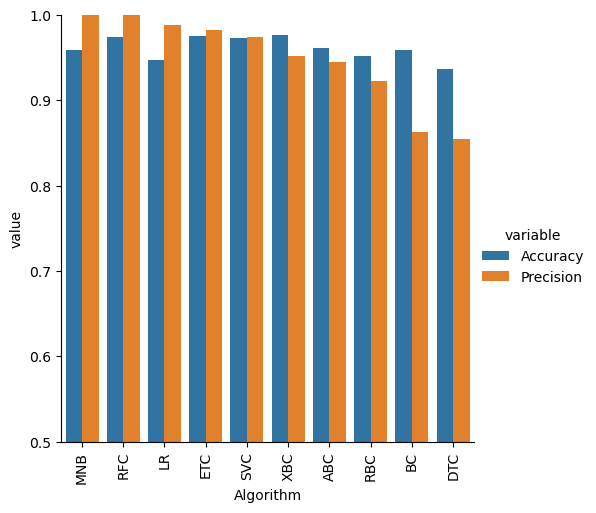

In [480]:
#making barplot of accuracy and precision 
sns.catplot(x='Algorithm', y='value', hue ='variable', data=performance_df1,kind='bar')
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

# Model Improvement 

In [481]:
#for better performance lets improve the max_paratemeters feature of the model 
from sklearn.feature_extraction.text import TfidfVectorizer 
tfidf = TfidfVectorizer(max_features=3000)

In [490]:
X = tfidf.fit_transform(df['transform_text']).toarray()

In [491]:
X.shape

(5169, 3000)

In [492]:
y=df['target'].values

In [498]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [499]:
from sklearn.model_selection import train_test_split

In [516]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2) 

In [517]:
#since we are using MultinomialNb lets import that one .... 
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score,classification_report

In [518]:
#training another model 
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2,average='macro'))

0.9593810444874274
[[896   0]
 [ 42  96]]
0.9776119402985075


In [519]:
#importing few other model for better learning 
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.ensemble import AdaBoostClassifier 
from sklearn.ensemble import BaggingClassifier 
from sklearn.ensemble import ExtraTreesClassifier 
from sklearn.ensemble import GradientBoostingClassifier 
from xgboost import XGBClassifier 

In [520]:
#making object of all the models accordingly 
lr = LogisticRegression()
svc = SVC(kernel ='sigmoid')
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth =5)
##knc = KNeighborsClassifier()
rfc = RandomForestClassifier(n_estimators = 50, random_state = 2)
abc = AdaBoostClassifier(n_estimators = 50, random_state = 2)
bc = BaggingClassifier(n_estimators = 50, random_state = 2)
etc = ExtraTreesClassifier(n_estimators = 50, random_state = 2)
rbc =GradientBoostingClassifier(n_estimators = 50, random_state = 2)
xbc = XGBClassifier(n_estimators = 50, random_state = 2)

In [521]:
#making dictionary of machine learning algorithm 
clfs = {
    'LR':lr,
    'SVC':svc,
    'MNB':mnb,
    'DTC':dtc,
    ##'KNC':knc,
    'RFC':rfc,
    'ABC':abc,
    'BC':bc,
    'ETC':etc,
    'RBC':rbc,
    'XBC':xbc
}

In [522]:
def train_classifier(clf,X_train, y_train,X_test, y_test):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    
    return accuracy,precision
    

In [523]:
accuracy_scores =[]
precision_scores =[]

for name , clf in clfs.items():
    current_accuracy, current_precision = train_classifier(clf, X_train,y_train,X_test, y_test)
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  LR
Accuracy -  0.9468085106382979
Precision -  0.9882352941176471
For  SVC
Accuracy -  0.9729206963249516
Precision -  0.9741379310344828
For  MNB
Accuracy -  0.9593810444874274
Precision -  1.0
For  DTC
Accuracy -  0.937137330754352
Precision -  0.8543689320388349
For  RFC
Accuracy -  0.9738878143133463
Precision -  1.0
For  ABC
Accuracy -  0.9613152804642167
Precision -  0.9454545454545454
For  BC
Accuracy -  0.9584139264990329
Precision -  0.8625954198473282
For  ETC
Accuracy -  0.9758220502901354
Precision -  0.9829059829059829
For  RBC
Accuracy -  0.9516441005802708
Precision -  0.9230769230769231
For  XBC
Accuracy -  0.97678916827853
Precision -  0.9523809523809523


In [524]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)

In [525]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaling':accuracy_scores,'Precision_scaling':precision_scores}).sort_values('Precision_scaling',ascending=False)

In [526]:
new_df = performance_df.merge(temp_df,on='Algorithm')

In [527]:
new_df_scaled = new_df.merge(temp_df,on='Algorithm')

In [528]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_num_chars':accuracy_scores,'Precision_num_chars':precision_scores}).sort_values('Precision_num_chars',ascending=False)

In [529]:
#checking the coparision data of model with and without max_feature 
new_df_scaled.merge(temp_df,on='Algorithm')

,Algorithm,Accuracy,Precision,Accuracy_scaling_x,Precision_scaling_x,Accuracy_scaling_y,Precision_scaling_y,Accuracy_num_chars,Precision_num_chars
0,MNB,0.959381,1.000000,0.959381,1.000000,0.959381,1.000000,0.959381,1.000000
1,RFC,0.973888,1.000000,0.973888,1.000000,0.973888,1.000000,0.973888,1.000000
2,LR,0.946809,0.988235,0.946809,0.988235,0.946809,0.988235,0.946809,0.988235
3,ETC,0.975822,0.982906,0.975822,0.982906,0.975822,0.982906,0.975822,0.982906
4,SVC,0.972921,0.974138,0.972921,0.974138,0.972921,0.974138,0.972921,0.974138
5,XBC,0.976789,0.952381,0.976789,0.952381,0.976789,0.952381,0.976789,0.952381
6,ABC,0.961315,0.945455,0.961315,0.945455,0.961315,0.945455,0.961315,0.945455
7,RBC,0.951644,0.923077,0.951644,0.923077,0.951644,0.923077,0.951644,0.923077
8,BC,0.958414,0.862595,0.958414,0.862595,0.958414,0.862595,0.958414,0.862595
9,DTC,0.937137,0.854369,0.937137,0.854369,0.937137,0.854369,0.937137,0.854369
